# Inspect swing-shape clustering

- `swings` - competitive-swing model table (`data/swings_model.parquet`)
- `assign` - per-swing cluster assignment (`play_id, batter_id, cluster, resp_max`)
- `summary` - per-(batter, cluster) raw-unit centroids + usage weight
- `rep` - per-batter repertoire (`k, bic, effective_shapes`, ...)
- `swc` - `swings` left-joined with `assign` (per-swing frame with features + context + value + cluster)

Helpers: `SHAPE` (5 clustering features), `RAW_SHAPE` (unmirrored), `by_name(s)` to find a batter_id.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

ROOT = next(p for p in [Path.cwd(), Path.cwd().parent] if (p / 'data').exists())
DATA = ROOT / 'data'
print('data dir:', DATA)

SHAPE = ['swing_path_tilt', 'swing_length', 'bat_speed', 'vert_attack_angle', 'horz_attack_angle_pull']
RAW_SHAPE = ['swing_path_tilt', 'swing_length', 'bat_speed', 'vert_attack_angle', 'horz_attack_angle']

data dir: c:\Users\theo.an-yeung\Desktop\Driveline\swing-repertoire\data


In [2]:
swings  = pd.read_parquet(DATA / 'swings_model.parquet')
assign  = pd.read_parquet(DATA / 'cluster_assignments.parquet')
summary = pd.read_parquet(DATA / 'cluster_summary.parquet')
rep     = pd.read_parquet(DATA / 'batter_repertoire.parquet')

for name, d in [('swings', swings), ('assign', assign), ('summary', summary), ('rep', rep)]:
    print(f'{name:8s} {d.shape}')

swings   (795723, 39)
assign   (780328, 5)
summary  (1954, 12)
rep      (703, 12)


In [3]:
# per-swing analysis frame: features + context + value + assigned cluster (cohort swings only)
swc = swings.merge(assign[['play_id', 'cluster', 'resp_max']], on='play_id', how='inner')
print('swc', swc.shape)

def by_name(s):
    """Return rep rows whose batter_full_name contains s (case-insensitive)."""
    return rep[rep.batter_full_name.str.contains(s, case=False, na=False)]

swc (780328, 41)


In [4]:
# quick peek
display(rep.head())
display(summary.head())
display(swc.head())

,batter_id,batter_stand,batter_full_name,label,n_swings,k,bic,min_weight,min_comp_n,usage_entropy,effective_shapes,shape_dispersion
0,444482,L,David Peralta,David Peralta,500,2,5366.4,0.4940,247,0.693,2.00,2.217
1,453568,L,Charlie Blackmon,Charlie Blackmon,817,4,8797.7,0.1151,94,1.310,3.70,2.426
2,455117,R,Martín Maldonado,Martín Maldonado,449,2,4969.0,0.4878,219,0.693,2.00,2.001
3,456781,R,Donovan Solano,Donovan Solano,888,2,9747.7,0.4989,443,0.693,2.00,2.081
4,457705,R,Andrew McCutchen,Andrew McCutchen,1906,3,21290.5,0.1516,289,0.941,2.56,1.853


,batter_id,batter_stand,batter_full_name,label,cluster,n,weight,swing_path_tilt_mean,swing_length_mean,bat_speed_mean,vert_attack_angle_mean,horz_attack_angle_mean
0,444482,L,David Peralta,David Peralta,0,253,0.5060,29.111,6.521,69.200,-0.704,12.771
1,444482,L,David Peralta,David Peralta,1,247,0.4940,32.766,7.761,72.265,11.703,-14.840
2,453568,L,Charlie Blackmon,Charlie Blackmon,0,314,0.3843,26.807,6.787,67.938,7.602,-0.437
3,453568,L,Charlie Blackmon,Charlie Blackmon,1,199,0.2436,33.064,7.819,66.615,16.939,-17.820
4,453568,L,Charlie Blackmon,Charlie Blackmon,2,210,0.2570,36.711,7.232,67.525,6.379,-2.606


,play_id,game_pk,game_date,game_year,batter_id,batter_full_name,batter_stand,pitcher_id,balls,strikes,outs_when_up,plate_x,plate_z,plate_zone,pitch_type,on_1b_id,on_2b_id,on_3b_id,delta_run_exp,woba,xwoba,exit_velo,launch_angle,bearing_angle,pitch_outcome,pa_outcome,is_whiff,is_contact,is_bip,ball_bat_intercept_y,sz_top,sz_bot,height,swing_path_tilt,swing_length,bat_speed,vert_attack_angle,horz_attack_angle,horz_attack_angle_pull,cluster,resp_max
0,001848c7-9251-4b7e-8311-8679799076c1,745408,2024-06-06,2024,444482,David Peralta,L,677944,0,0,2,-0.093388,2.12002,8.0,FF,630105.0,665487.0,NaN,-0.048,NaN,NaN,66.6,48.0,NaN,S,NaN,0,1,0,1.389080,3.51,1.69,73,38.5906,7.4,69.4,3.67121,-9.17984,9.17984,1,0.729
1,0168c81f-8927-4514-8f83-38b5514293fd,746515,2024-08-17,2024,444482,David Peralta,L,664875,0,1,2,-0.415410,2.41925,4.0,ST,673490.0,NaN,592518.0,-0.241,0.0,0.053,72.8,-17.0,37.8601,X,field_out,0,1,1,1.759620,3.51,1.69,73,25.2650,7.9,62.6,7.26082,-8.65910,8.65910,1,1.000
2,033e01bc-7bc6-42e1-8712-8b2264ff048d,745372,2024-09-07,2024,444482,David Peralta,L,657277,2,1,2,0.010009,1.33547,14.0,CH,NaN,NaN,NaN,-0.084,NaN,NaN,NaN,NaN,NaN,S,NaN,1,0,0,1.538670,3.51,1.69,73,38.4268,8.1,70.3,9.30411,-11.97710,11.97710,1,0.998
3,0377c827-08cd-4744-831f-e044991b30ce,746714,2024-05-23,2024,444482,David Peralta,L,608371,0,0,2,-0.375680,2.86055,4.0,FF,NaN,NaN,NaN,-0.041,NaN,NaN,74.3,45.0,NaN,S,NaN,0,1,0,0.472725,3.51,1.69,73,29.7084,7.0,69.4,3.23382,8.27273,-8.27273,0,0.784
4,03969283-ba94-4433-b1ce-ab980b92a021,746938,2024-06-30,2024,444482,David Peralta,L,686580,2,0,2,0.091078,1.47829,14.0,FC,NaN,NaN,673490.0,-0.046,NaN,NaN,NaN,NaN,NaN,S,NaN,1,0,0,1.990730,3.51,1.69,73,35.3725,8.4,74.1,17.21380,-22.27910,22.27910,1,0.999


## Luis Arraez Inspection 

7 Unique Swing Shapes - What Differentiates Each

In [5]:
ex = summary[summary.batter_full_name.str.contains('Arraez', case=False, na=False)]
cols = ["batter_full_name", "cluster", "n", "weight"] + [f"{c}_mean" for c in RAW_SHAPE]
display(ex[cols].sort_values("cluster").reset_index(drop=True))

,batter_full_name,cluster,n,weight,swing_path_tilt_mean,swing_length_mean,bat_speed_mean,vert_attack_angle_mean,horz_attack_angle_mean
0,Luis Arraez,0,697,0.2507,36.379,6.088,62.525,5.582,10.012
1,Luis Arraez,1,600,0.2158,33.796,5.878,65.181,11.845,-3.237
2,Luis Arraez,2,511,0.1838,33.801,4.877,57.009,-1.034,16.084
3,Luis Arraez,3,330,0.1187,48.198,6.386,63.557,10.630,-6.970
4,Luis Arraez,4,386,0.1388,40.325,5.508,62.554,-3.195,16.977
5,Luis Arraez,5,215,0.0773,36.639,6.854,64.163,23.110,-15.634
6,Luis Arraez,6,41,0.0147,37.113,6.261,59.361,9.548,-0.811


## Swing-shape cards (Baseball-Savant style)

`swing_cards(name)` — a **static** comparison matrix for one hitter: **one row per cluster**,
columns = the Savant swing diagrams. Read down a column to compare shapes.

| column | what it shows | source metric |
|---|---|---|
| **Attack angle** | vertical direction of the sweet spot at contact (red arrow vs flat) | `vert_attack_angle` |
| **Attack direction** | top-down heading in the hitter's real field orientation — the arrow leans toward their **pull** field (RHH pull = screen-left/LF, LHH pull = screen-right/RF), with the PULL/OPPO labels flipped to match handedness | `horz_attack_angle_pull` (pull frame; screen-flipped for LHH) |
| **Swing tilt** | plane tilt from flat (0°) toward steep | `swing_path_tilt` |
| **Bat speed** | mph vs the MLB-average tick | `bat_speed` |

Each panel shows the **MLB average** (from the cohort) for reference. `swing_cards(name, save=...)`
writes a PNG.

Every diagram is a *direct* function of a contact-point metric — Statcast gives swing geometry only
*at* contact, not the full bat trajectory (`research-design.md` Limitation #1), so no swing-path
sweep is reconstructed.

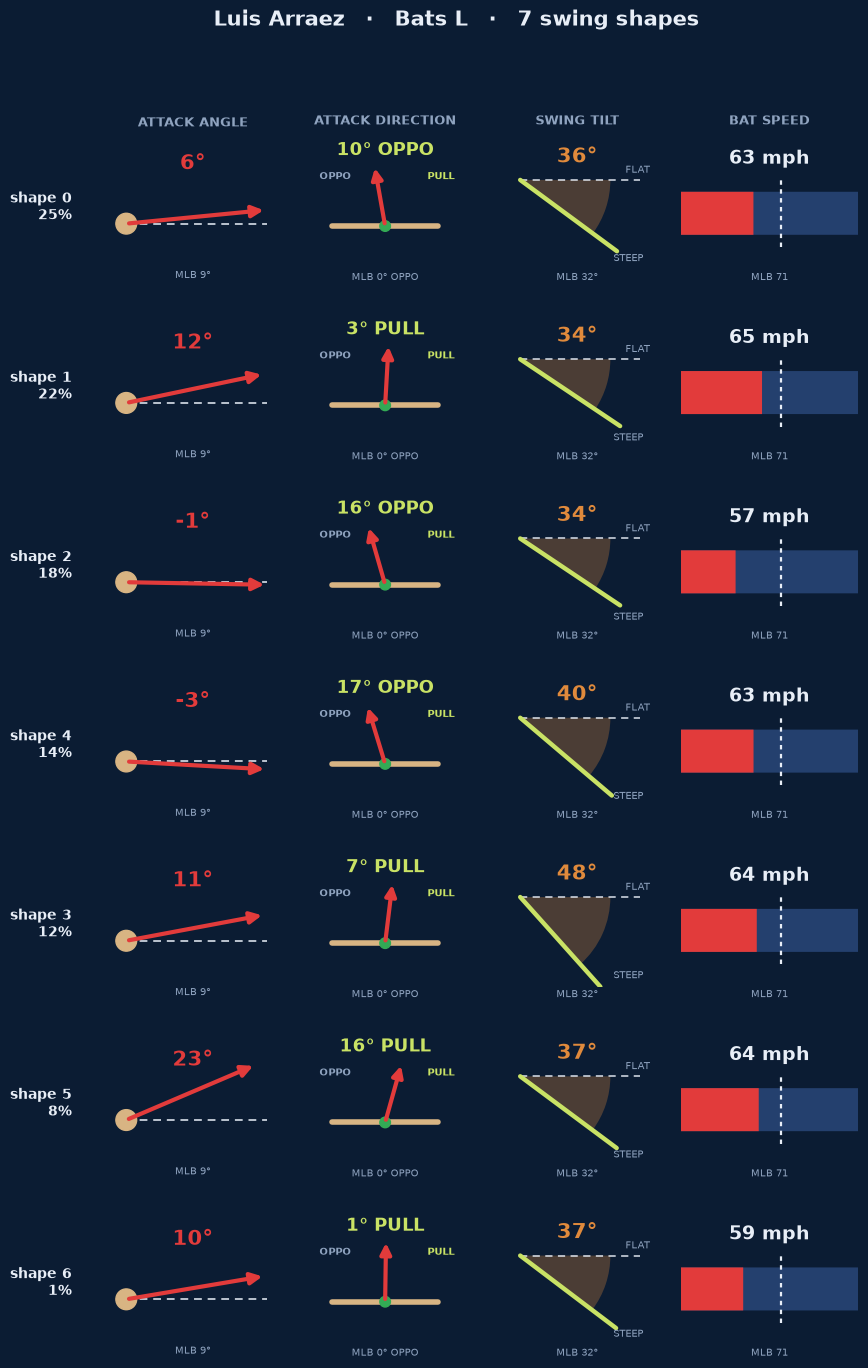

In [22]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Wedge, Circle, FancyBboxPatch

# Savant-style palette
BG, INK, MUT = '#0b1c33', '#e8eef7', '#8fa3bf'
RED, TAN, LIME, ORNG, GRID = '#e23b3b', '#d8b483', '#c9e265', '#e08a3c', '#24406e'

# MLB-average references, from the clustered cohort
LEAGUE = {c: swc[c].mean() for c in
          ['bat_speed', 'vert_attack_angle', 'horz_attack_angle_pull', 'swing_path_tilt']}


def _off(ax):
    ax.set_facecolor(BG); ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)


def _p_aa(ax, r):
    _off(ax); ax.set_aspect('equal'); ax.set_xlim(-1.15, 1.25); ax.set_ylim(-0.6, 1.05)
    a = np.radians(r.vaa)
    ax.add_patch(Circle((-0.85, 0), 0.14, color=TAN, zorder=3))
    ax.plot([-0.85, 1.05], [0, 0], color=INK, ls=(0, (4, 3)), lw=1.4, alpha=.8)
    ax.add_patch(FancyArrowPatch((-0.85, 0), (-0.85 + 1.9*np.cos(a), 1.9*np.sin(a)),
                 arrowstyle='-|>', mutation_scale=17, color=RED, lw=3, zorder=4))
    ax.text(0.5, 0.94, f"{r.vaa:.0f}°", transform=ax.transAxes, ha='center', va='top',
            color=RED, fontsize=15, fontweight='bold')


def _p_dir(ax, r):
    _off(ax); ax.set_aspect('equal'); ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.0, 1.15)
    # haa is in the pull frame (+ = pull for both hands). A LHH's pull is right field, so flip the
    # screen orientation for lefties: the arrow leans toward the hitter's real pull side and the
    # PULL/OPPO labels move with it. Magnitude + pull/oppo text are unchanged (frame-invariant).
    s = -1.0 if getattr(r, 'stand', 'R') == 'L' else 1.0
    ang = np.radians(r.haa) * s
    ax.plot([-0.9, 0.9], [-0.25, -0.25], color=TAN, lw=4, solid_capstyle='round')
    ax.add_patch(Circle((0, -0.25), 0.09, color='#3a5', zorder=3))
    ax.add_patch(FancyArrowPatch((0, -0.25), (-np.sin(ang)*1.05, -0.25 + np.cos(ang)*1.05),
                 arrowstyle='-|>', mutation_scale=16, color=RED, lw=3, zorder=4))
    pull_x, oppo_x = ((-1.12, 0.72) if s > 0 else (0.72, -1.12))
    ax.text(pull_x, 0.55, 'PULL', color=LIME, fontsize=7.5, fontweight='bold')
    ax.text(oppo_x, 0.55, 'OPPO', color=MUT, fontsize=7.5, fontweight='bold')
    ax.text(0.5, 1.02, f"{abs(r.haa):.0f}° {'PULL' if r.haa >= 0 else 'OPPO'}",
            transform=ax.transAxes, ha='center', va='top', color=LIME, fontsize=13, fontweight='bold')


def _p_tilt(ax, r):
    _off(ax); ax.set_aspect('equal'); ax.set_xlim(-0.2, 2.1); ax.set_ylim(-1.5, 0.6)
    t = r.tilt
    ax.add_patch(Wedge((0, 0), 1.5, -t, 0, facecolor=ORNG, alpha=.30))
    ax.plot([0, 2.0], [0, 0], color=INK, ls=(0, (4, 3)), lw=1.3, alpha=.8)
    ax.plot([0, 2.0*np.cos(np.radians(t))], [0, -2.0*np.sin(np.radians(t))], color=LIME, lw=3.2,
            solid_capstyle='round')
    ax.text(1.75, 0.12, 'FLAT', color=MUT, fontsize=7); ax.text(1.55, -1.35, 'STEEP', color=MUT, fontsize=7)
    ax.text(0.5, 0.98, f"{r.tilt:.0f}°", transform=ax.transAxes, ha='center', va='top',
            color=ORNG, fontsize=15, fontweight='bold')


def _p_speed(ax, r):
    _off(ax); ax.set_xlim(40, 95); ax.set_ylim(0, 1)
    ax.add_patch(FancyBboxPatch((40, 0.28), 55, 0.34, boxstyle='round,pad=0.02',
                 mutation_aspect=0.02, facecolor=GRID, edgecolor='none'))
    ax.add_patch(FancyBboxPatch((40, 0.28), r.speed-40, 0.34, boxstyle='round,pad=0.02',
                 mutation_aspect=0.02, facecolor=RED, edgecolor='none'))
    ax.plot([LEAGUE['bat_speed']]*2, [0.18, 0.72], color=INK, lw=1.6, ls=(0, (2, 2)))
    ax.text(0.5, 0.96, f"{r.speed:.0f} mph", transform=ax.transAxes, ha='center', va='top',
            color=INK, fontsize=14, fontweight='bold')


COLS = [('ATTACK ANGLE', _p_aa, f"MLB {LEAGUE['vert_attack_angle']:.0f}°"),
        ('ATTACK DIRECTION', _p_dir,
         f"MLB {abs(LEAGUE['horz_attack_angle_pull']):.0f}° {'PULL' if LEAGUE['horz_attack_angle_pull'] >= 0 else 'OPPO'}"),
        ('SWING TILT', _p_tilt, f"MLB {LEAGUE['swing_path_tilt']:.0f}°"),
        ('BAT SPEED', _p_speed, f"MLB {LEAGUE['bat_speed']:.0f}")]


def swing_cards(name, save=None):
    """Static Savant-style card matrix (one row per cluster) for one hitter."""
    d = swc[swc.batter_full_name.str.contains(name, case=False, na=False)]
    who = d.batter_full_name.unique()
    if len(who) != 1:
        raise ValueError(f'{name!r} matches {list(who)} - be more specific')
    full, stand = who[0], d.batter_stand.mode().iloc[0]
    g = (d.groupby('cluster').agg(n=('play_id', 'size'), tilt=('swing_path_tilt', 'mean'),
         speed=('bat_speed', 'mean'), vaa=('vert_attack_angle', 'mean'),
         haa=('horz_attack_angle_pull', 'mean')).reset_index())
    g['weight'] = g.n / g.n.sum(); g['stand'] = stand; g = g.sort_values('weight', ascending=False)
    k, nc = len(g), len(COLS)
    fig, axes = plt.subplots(k, nc, figsize=(2.05*nc, 2.02*k),
                             gridspec_kw=dict(wspace=0.08, hspace=0.42))
    axes = np.atleast_2d(axes); fig.patch.set_facecolor(BG)
    for j, (title, _, _) in enumerate(COLS):
        axes[0, j].set_title(title, color=MUT, fontsize=9.5, fontweight='bold', pad=14)
    for i, (_, r) in enumerate(g.iterrows()):
        axes[i, 0].text(-0.18, 0.5, f"shape {int(r.cluster)}\n{r.weight*100:.0f}%",
                        transform=axes[i, 0].transAxes, ha='right', va='center',
                        color=INK, fontsize=10, fontweight='bold')
        for j, (_, fn, avg) in enumerate(COLS):
            fn(axes[i, j], r)
            if avg:
                axes[i, j].text(0.5, -0.02, avg, transform=axes[i, j].transAxes,
                                ha='center', va='top', color=MUT, fontsize=7)
    fig.suptitle(f"{full}   ·   Bats {stand}   ·   {k} swing shapes", color=INK,
                 fontsize=15, fontweight='bold', y=0.995)
    fig.subplots_adjust(left=0.07, right=0.99, top=0.90, bottom=0.05)
    if save:
        fig.savefig(save, dpi=130, facecolor=BG, bbox_inches='tight'); print('wrote', save)
    return fig


swing_cards('Arraez');

## Cluster usage by game state (heatmap)

`usage_heatmap(name)` — pass any hitter's name (substring match). Each cell is **P(cluster | game state)**: within a situation, the share of that hitter's swings falling in each shape (columns sum to 100%).

In [14]:
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap

# Baseball-Savant-style diverging palette, lightened (soft blue -> off-white -> soft red)
SAVANT = LinearSegmentedColormap.from_list('savant_light', ['#7EA6D6', '#FBFBFB', '#E38A8A'])
# fastballs = four-seam, sinker, cutter, generic fastball (FT/two-seamer folded into SI by Statcast);
# everything else (SL/ST/CU/KC/SV/CH/FS/FO/KN/...) = secondary
FASTBALLS = {'FF', 'SI', 'FC', 'FT', 'FA'}

def usage_heatmap(name):
    """Cluster-usage heatmap by game state for one hitter (substring match on batter_full_name).
    Each cell = P(cluster | state) as a %, columns sum to 100. Color runs column-wise: within a
    game state, red = the shape used most there, blue = least. Returns the styled table."""
    d = swc[swc.batter_full_name.str.contains(name, case=False, na=False)]
    names = d.batter_full_name.unique()
    if len(names) == 0:
        raise ValueError(f'no batter matches {name!r}')
    if len(names) > 1:
        raise ValueError(f'{name!r} matches {len(names)} batters: {list(names)} — be more specific')
    full = names[0]
    k = int(d.cluster.max()) + 1
    b, s, o, pt = d.balls, d.strikes, d.outs_when_up, d.pitch_type
    on1, on2, on3 = d.on_1b_id.notna(), d.on_2b_id.notna(), d.on_3b_id.notna()
    is_fb = pt.isin(FASTBALLS)

    masks = {
        'All':     None,
        '0-0':     (b == 0) & (s == 0),
        '2 strk':  s == 2,
        '0-2':     (b == 0) & (s == 2),
        'Full':    (b == 3) & (s == 2),
        'vs FB':   is_fb,
        'vs Sec':  pt.notna() & ~is_fb,
        'Empty':   ~(on1 | on2 | on3),
        'RISP':    on2 | on3,
        '0 out':   o == 0,
        '1 out':   o == 1,
        '2 out':   o == 2,
    }
    dist = lambda m: ((d if m is None else d[m]).cluster
                      .value_counts(normalize=True).reindex(range(k), fill_value=0) * 100)
    usage = pd.DataFrame({nm: dist(m) for nm, m in masks.items()})
    usage.index.name = 'cluster'
    support = pd.Series({nm: (len(d) if m is None else int(m.sum())) for nm, m in masks.items()},
                        name='n swings').to_frame().T

    return (usage.style
            .background_gradient(cmap=SAVANT, axis=0, low=0.1, high=0.1)   # column-wise: red = most-used shape in that state
            .format('{:.0f}%')
            .set_caption(f'{full} - cluster usage % by game state'
                         ))
    
usage_heatmap('Arraez')

,All,0-0,2 strk,0-2,Full,vs FB,vs Sec,Empty,RISP,0 out,1 out,2 out
cluster,,,,,,,,,,,,
0,25%,20%,30%,26%,23%,21%,33%,24%,26%,26%,24%,26%
1,22%,27%,17%,16%,29%,24%,16%,21%,22%,21%,22%,23%
2,18%,17%,20%,21%,20%,25%,5%,20%,17%,18%,19%,18%
3,12%,12%,13%,15%,8%,9%,17%,12%,14%,12%,12%,12%
4,14%,14%,11%,11%,15%,17%,8%,15%,11%,14%,15%,12%
5,8%,8%,6%,7%,4%,3%,17%,7%,8%,8%,7%,9%
6,1%,1%,2%,3%,1%,1%,2%,1%,2%,2%,1%,1%


## Shape Dispersion Range of Values 

In [13]:
display(rep[rep.shape_dispersion.notnull() & rep.k < 1].sort_values("shape_dispersion", ascending=False)) 

,batter_id,batter_stand,batter_full_name,label,n_swings,k,bic,min_weight,min_comp_n,usage_entropy,effective_shapes,shape_dispersion
446,676701,R,Alan Trejo,Alan Trejo,183,4,2154.9,0.0164,3,1.136,3.11,3.304
156,641432,L,Willie Calhoun,Willie Calhoun,375,2,4389.3,0.0987,37,0.322,1.38,3.277
620,682987,L,Spencer Jones,Spencer Jones,202,2,2031.4,0.3317,67,0.635,1.89,3.114
407,671286,R,Johnathan Rodríguez,Johnathan Rodríguez,228,2,2366.1,0.4123,94,0.678,1.97,3.030
41,547989,R,José Abreu,José Abreu,170,2,1921.1,0.3353,57,0.638,1.89,2.985
...,...,...,...,...,...,...,...,...,...,...,...,...
489,681146,R,Jonah Bride,Jonah Bride,544,2,6360.5,0.4210,229,0.681,1.98,1.531
666,700337,L,Edgar Quero,Edgar Quero (L),654,2,7556.1,0.4893,320,0.693,2.00,1.509
373,669289,R,Santiago Espinal,Santiago Espinal,1305,2,15066.9,0.3502,457,0.648,1.91,1.432
392,670097,R,Zack Short,Zack Short,325,2,3846.1,0.1477,48,0.419,1.52,1.365
